# INDILEX Direct vs Chunk-Candidate Dataset Visualization & Interpretation

This notebook compares the two routed datasets and helps interpret:
- row counts and integrity
- case-type composition
- language composition
- judgment character and word-length distributions
- annotation completeness
- route separation around the boundary
- case-type-specific length behavior
- direct/chunk proportions by case type
- longest and shortest cases
- overlap and duplicate checks
- useful summary tables for research reporting

The notebook does not modify either source CSV.


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)


/mnt/Data/yashv7523/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/mnt/Data/yashv7523/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
# ============================================================
# CONFIGURATION — change paths only if needed
# ============================================================

DIRECT_CSV = "INDILEX_direct_annotation.csv"
CHUNK_CSV  = "INDILEX_chunk_candidates.csv"

OUTPUT_DIR = Path("visualization_reports")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ANNOTATION_COLUMNS = [
    "subject",
    "object",
    "objective_aspect",
    "subjective_aspect",
    "legal_provision",
    "reasoning",
]

print("Configuration loaded.")


Configuration loaded.


In [4]:
# ============================================================
# LOAD DATA
# ============================================================

direct = pd.read_csv(DIRECT_CSV, encoding="utf-8-sig", low_memory=False)
chunk = pd.read_csv(CHUNK_CSV, encoding="utf-8-sig", low_memory=False)

direct["route"] = "direct"
chunk["route"] = "chunk_candidate"

combined = pd.concat([direct, chunk], ignore_index=True)

print("Direct rows:", len(direct))
print("Chunk rows :", len(chunk))
print("Total rows :", len(combined))


Direct rows: 471
Chunk rows : 271
Total rows : 742


In [5]:
# ============================================================
# BASIC INTEGRITY CHECKS
# ============================================================

print("Schema identical:", list(direct.columns[:-1]) == list(chunk.columns[:-1]))
print("Duplicate case_id in direct:", direct["case_id"].duplicated().sum())
print("Duplicate case_id in chunk :", chunk["case_id"].duplicated().sum())

overlap = set(direct["case_id"].astype(str)) & set(chunk["case_id"].astype(str))
print("case_id overlap across routes:", len(overlap))

assert len(overlap) == 0, "A case_id appears in both datasets."
assert len(combined) == len(direct) + len(chunk), "Row-count integrity failed."

print("✓ Basic split integrity checks passed.")


Schema identical: True
Duplicate case_id in direct: 0
Duplicate case_id in chunk : 0
case_id overlap across routes: 0
✓ Basic split integrity checks passed.


In [6]:
# ============================================================
# LENGTH METRICS
# ============================================================

combined["char_count"] = combined["judgment_text"].fillna("").astype(str).str.len()
combined["word_count"] = combined["judgment_text"].fillna("").astype(str).str.split().str.len()

length_summary = combined.groupby("route").agg(
    rows=("case_id", "size"),
    mean_chars=("char_count", "mean"),
    median_chars=("char_count", "median"),
    p90_chars=("char_count", lambda x: x.quantile(0.90)),
    max_chars=("char_count", "max"),
    mean_words=("word_count", "mean"),
    median_words=("word_count", "median"),
    p90_words=("word_count", lambda x: x.quantile(0.90)),
    max_words=("word_count", "max"),
).reset_index()

display(length_summary.round(2))


,route,rows,mean_chars,median_chars,p90_chars,max_chars,mean_words,median_words,p90_words,max_words
0,chunk_candidate,271,17090.66,14414.0,31596.0,32759,3143.16,2631.0,5706.0,6237
1,direct,471,2630.82,2168.0,4822.0,7742,463.62,371.0,871.0,1473


,route,rows,percent
0,direct,471,63.48
1,chunk_candidate,271,36.52


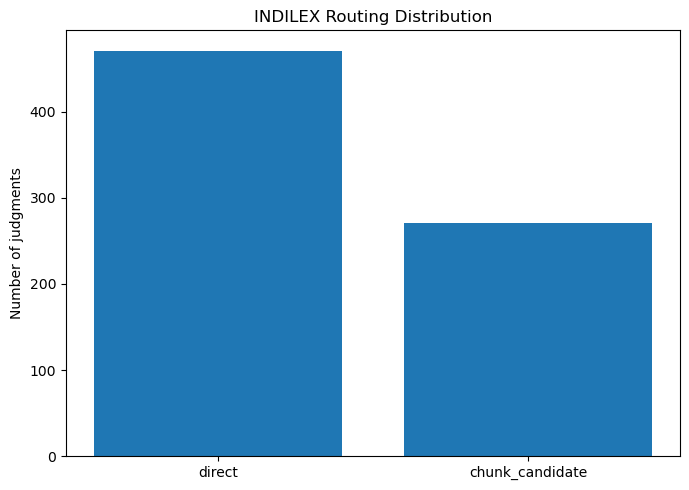

In [7]:
# ============================================================
# ROUTE SHARE
# ============================================================

route_counts = combined["route"].value_counts().rename_axis("route").reset_index(name="rows")
route_counts["percent"] = (100 * route_counts["rows"] / len(combined)).round(2)
display(route_counts)

plt.figure(figsize=(7, 5))
plt.bar(route_counts["route"], route_counts["rows"])
plt.ylabel("Number of judgments")
plt.title("INDILEX Routing Distribution")
plt.tight_layout()
plt.show()


route,chunk_candidate,direct,total,chunk_percent_within_case_type
case_type,,,,
Criminal,134,289,423,31.68
Administrative,80,89,169,47.34
Civil,31,64,95,32.63
Constitutional,26,29,55,47.27


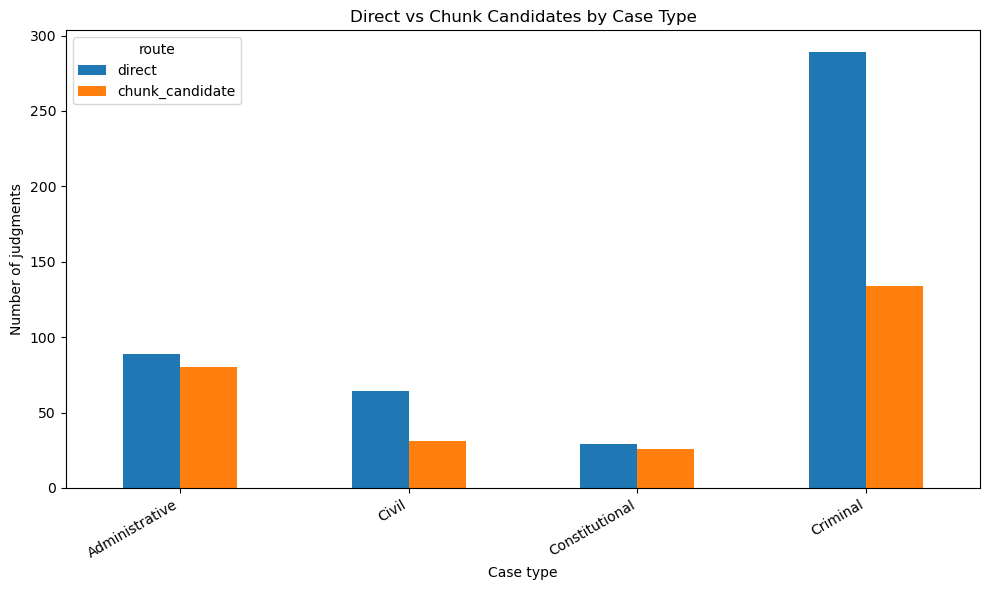

In [8]:
# ============================================================
# CASE-TYPE DISTRIBUTION BY ROUTE
# ============================================================

case_route = pd.crosstab(combined["case_type"], combined["route"])
case_route["total"] = case_route.sum(axis=1)

for route in ["direct", "chunk_candidate"]:
    if route not in case_route.columns:
        case_route[route] = 0

case_route["chunk_percent_within_case_type"] = (
    100 * case_route["chunk_candidate"] / case_route["total"]
).round(2)

display(case_route.sort_values("total", ascending=False))

plot_df = case_route[["direct", "chunk_candidate"]]
plot_df.plot(kind="bar", figsize=(10, 6))
plt.xlabel("Case type")
plt.ylabel("Number of judgments")
plt.title("Direct vs Chunk Candidates by Case Type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [9]:
# ============================================================
# LANGUAGE DISTRIBUTION
# ============================================================

language_route = pd.crosstab(combined["language"], combined["route"])
display(language_route)


route,chunk_candidate,direct
language,,
Hindi,271,471


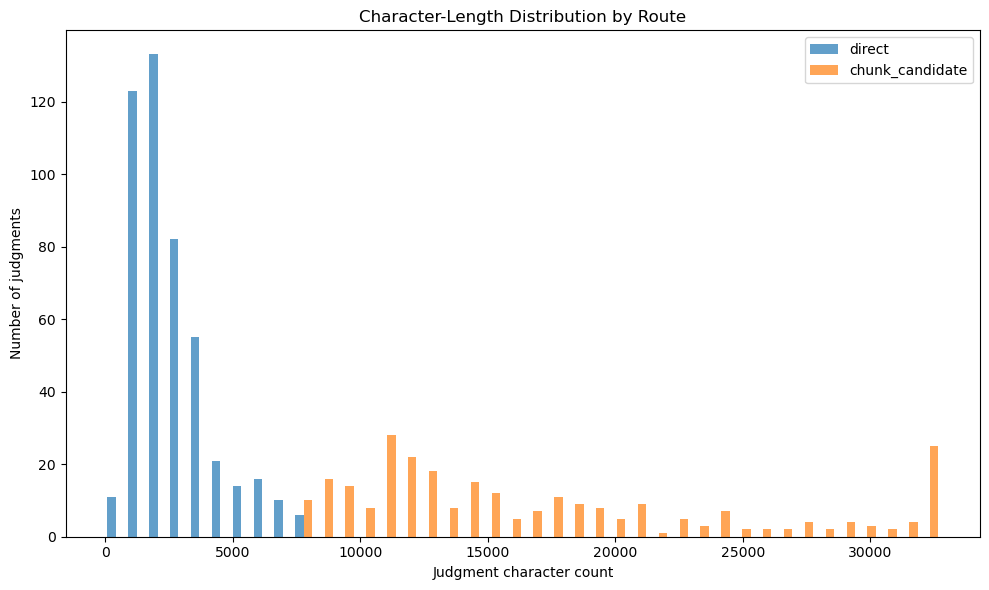

In [10]:
# ============================================================
# CHARACTER-LENGTH DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))
plt.hist(
    [
        combined.loc[combined["route"] == "direct", "char_count"],
        combined.loc[combined["route"] == "chunk_candidate", "char_count"],
    ],
    bins=40,
    label=["direct", "chunk_candidate"],
    alpha=0.7,
)
plt.xlabel("Judgment character count")
plt.ylabel("Number of judgments")
plt.title("Character-Length Distribution by Route")
plt.legend()
plt.tight_layout()
plt.show()


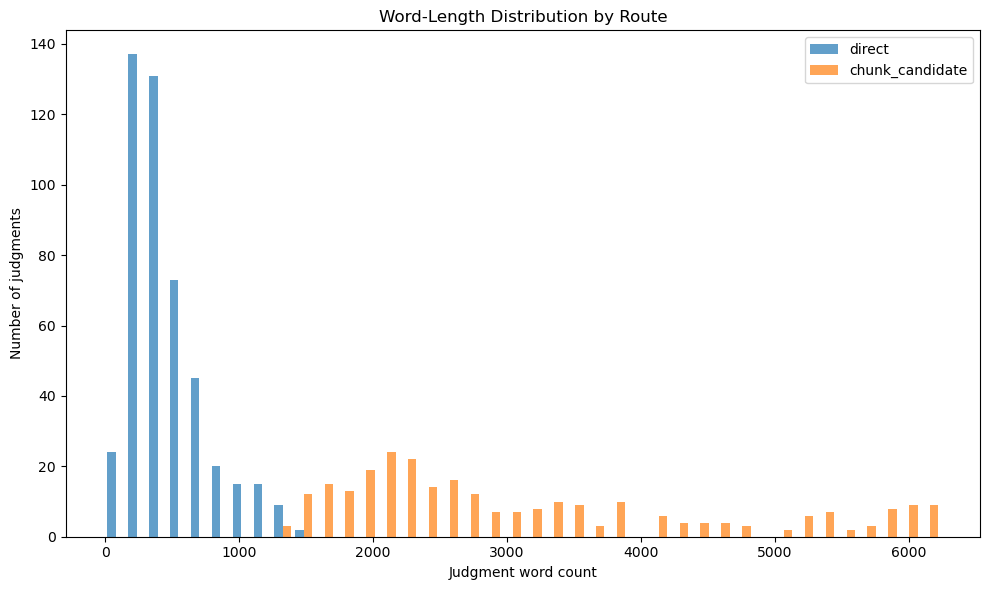

In [11]:
# ============================================================
# WORD-LENGTH DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))
plt.hist(
    [
        combined.loc[combined["route"] == "direct", "word_count"],
        combined.loc[combined["route"] == "chunk_candidate", "word_count"],
    ],
    bins=40,
    label=["direct", "chunk_candidate"],
    alpha=0.7,
)
plt.xlabel("Judgment word count")
plt.ylabel("Number of judgments")
plt.title("Word-Length Distribution by Route")
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
# ============================================================
# ROUTE BOUNDARY INSPECTION
# ============================================================

direct_boundary = (
    combined[combined["route"] == "direct"]
    .sort_values("char_count", ascending=False)
    [["case_id", "case_type", "char_count", "word_count"]]
    .head(20)
)

chunk_boundary = (
    combined[combined["route"] == "chunk_candidate"]
    .sort_values("char_count", ascending=True)
    [["case_id", "case_type", "char_count", "word_count"]]
    .head(20)
)

print("Largest DIRECT cases")
display(direct_boundary)

print("Smallest CHUNK-CANDIDATE cases")
display(chunk_boundary)


Largest DIRECT cases


,case_id,case_type,char_count,word_count
25,CHG_CRI_000074,Criminal,7742,1397
14,CHG_CRI_000028,Criminal,7736,1434
8,CHG_CIV_000004,Civil,7613,1473
19,CHG_CRI_000040,Criminal,7514,1390
213,DL_CIV_000002,Civil,7435,1327
11,CHG_CIV_000029,Civil,7372,1310
423,DEL_CON_000011,Constitutional,7248,1236
15,CHG_CRI_000029,Criminal,7234,1379
328,MP_CIV_000003,Civil,7178,1279
207,DEL_ADM_000016,Administrative,7142,1344


Smallest CHUNK-CANDIDATE cases


,case_id,case_type,char_count,word_count
551,CHG_CIV_000028,Civil,7751,1370
705,DL_CRIM_000063,Criminal,7812,1461
534,CHG_CIV_000009,Civil,7877,1434
692,DL_CRIM_000042,Criminal,7906,1386
701,DL_CRIM_000055,Criminal,7930,1426
720,MP_CON_000002,Constitutional,7959,1439
718,MP_ADM_000011,Administrative,8014,1439
685,DL_CRIM_000031,Criminal,8057,1592
732,DL_CRIM_000020,Criminal,8099,1534
611,CHG_CRI_000053,Criminal,8103,1531


In [13]:
# ============================================================
# LENGTH SUMMARY BY CASE TYPE AND ROUTE
# ============================================================

case_length_summary = combined.groupby(["case_type", "route"]).agg(
    rows=("case_id", "size"),
    median_chars=("char_count", "median"),
    mean_chars=("char_count", "mean"),
    max_chars=("char_count", "max"),
    median_words=("word_count", "median"),
    mean_words=("word_count", "mean"),
).reset_index()

display(case_length_summary.round(2))


,case_type,route,rows,median_chars,mean_chars,max_chars,median_words,mean_words
0,Administrative,chunk_candidate,80,15753.0,17328.31,32759,2791.5,3142.76
1,Administrative,direct,89,2255.0,2637.34,7142,374.0,457.55
2,Civil,chunk_candidate,31,14402.0,16691.74,32759,2637.0,3081.00
3,Civil,direct,64,2092.0,2583.69,7613,352.0,450.47
4,Constitutional,chunk_candidate,26,14230.5,17888.85,32759,2635.0,3284.38
5,Constitutional,direct,29,2009.0,2411.83,7248,349.0,414.93
6,Criminal,chunk_candidate,134,14028.5,16886.20,32759,2519.0,3130.38
7,Criminal,direct,289,2187.0,2661.23,7742,376.0,473.29


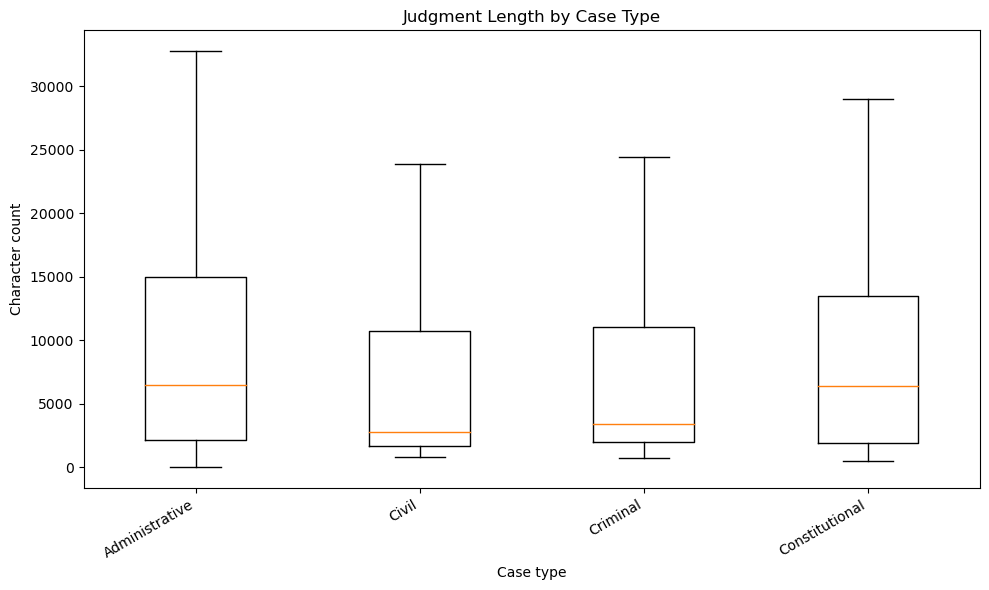

In [14]:
# ============================================================
# BOXPLOT: CHARACTER LENGTH BY CASE TYPE
# ============================================================

case_types = combined["case_type"].dropna().unique().tolist()
data_for_plot = [
    combined.loc[combined["case_type"] == ct, "char_count"].values
    for ct in case_types
]

plt.figure(figsize=(10, 6))
plt.boxplot(data_for_plot, labels=case_types, showfliers=False)
plt.xlabel("Case type")
plt.ylabel("Character count")
plt.title("Judgment Length by Case Type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [15]:
# ============================================================
# ANNOTATION COMPLETENESS
# ============================================================

MISSING_STRINGS = {"", "nan", "none", "null", "na", "n/a"}

def is_missing(x):
    if x is None:
        return True
    try:
        if pd.isna(x):
            return True
    except Exception:
        pass
    return str(x).strip().lower() in MISSING_STRINGS

records = []
for route, df in [("direct", direct), ("chunk_candidate", chunk)]:
    for col in ANNOTATION_COLUMNS:
        missing = int(df[col].apply(is_missing).sum()) if col in df.columns else len(df)
        records.append({
            "route": route,
            "annotation_field": col,
            "rows": len(df),
            "missing": missing,
            "present": len(df) - missing,
            "missing_percent": round(100 * missing / len(df), 2) if len(df) else 0
        })

annotation_missing = pd.DataFrame(records)
display(annotation_missing)


,route,annotation_field,rows,missing,present,missing_percent
0,direct,subject,471,0,471,0.00
1,direct,object,471,0,471,0.00
2,direct,objective_aspect,471,0,471,0.00
3,direct,subjective_aspect,471,0,471,0.00
4,direct,legal_provision,471,471,0,100.00
5,direct,reasoning,471,471,0,100.00
6,chunk_candidate,subject,271,14,257,5.17
7,chunk_candidate,object,271,14,257,5.17
8,chunk_candidate,objective_aspect,271,14,257,5.17
9,chunk_candidate,subjective_aspect,271,14,257,5.17


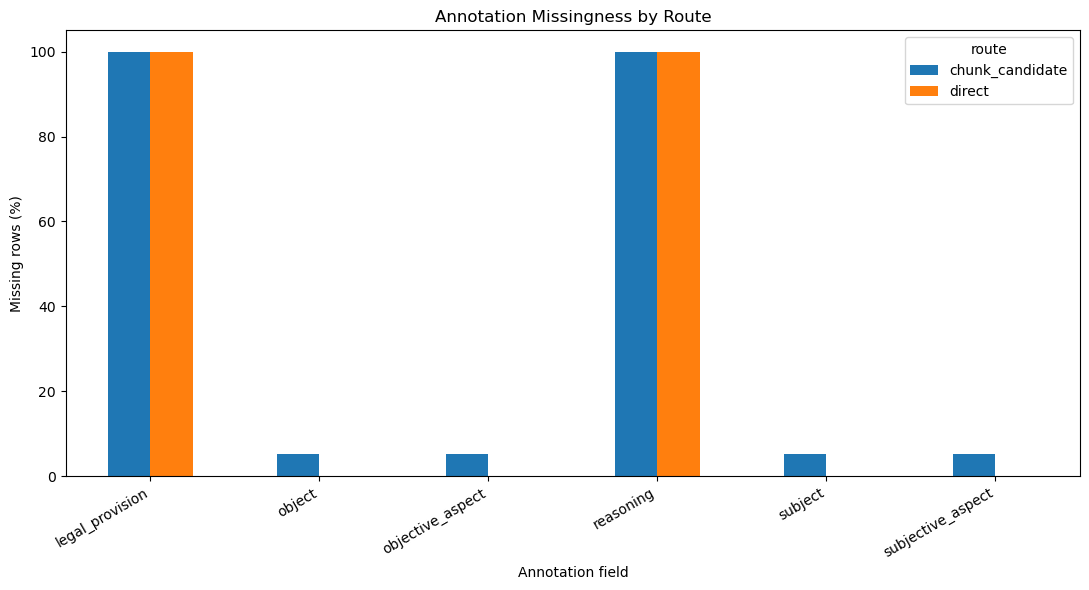

In [16]:
# ============================================================
# ANNOTATION MISSINGNESS VISUALIZATION
# ============================================================

pivot_missing = annotation_missing.pivot(
    index="annotation_field",
    columns="route",
    values="missing_percent"
)

pivot_missing.plot(kind="bar", figsize=(11, 6))
plt.xlabel("Annotation field")
plt.ylabel("Missing rows (%)")
plt.title("Annotation Missingness by Route")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [17]:
# ============================================================
# LONGEST JUDGMENTS
# ============================================================

longest = combined.sort_values("char_count", ascending=False)[
    ["case_id", "case_type", "route", "char_count", "word_count"]
].head(30)

display(longest)


,case_id,case_type,route,char_count,word_count
717,MP_ADM_000010,Administrative,chunk_candidate,32759,6055
563,CHG_CON_000012,Constitutional,chunk_candidate,32759,6129
571,CHG_CRI_000001,Criminal,chunk_candidate,32759,6187
646,DEL_ADM_000018,Administrative,chunk_candidate,32759,6065
632,CHG_CRI_000080,Criminal,chunk_candidate,32759,5880
715,MP_ADM_000006,Administrative,chunk_candidate,32759,6172
651,DL_CIV_000003,Civil,chunk_candidate,32759,5854
508,CHG_ADM_000045,Administrative,chunk_candidate,32759,5986
556,CHG_CON_000005,Constitutional,chunk_candidate,32759,6108
496,CHG_ADM_000031,Administrative,chunk_candidate,32759,5840


In [18]:
# ============================================================
# SIMPLE DUPLICATE-TEXT CHECK
# ============================================================

normalized = (
    combined["judgment_text"]
    .fillna("")
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

combined["_normalized_text"] = normalized
duplicate_text_mask = (
    combined["_normalized_text"].ne("") &
    combined["_normalized_text"].duplicated(keep=False)
)

duplicate_text_rows = combined[duplicate_text_mask][
    ["case_id", "case_type", "route", "char_count"]
].copy()

print("Exact normalized duplicate-text rows:", len(duplicate_text_rows))
display(duplicate_text_rows.head(50))


Exact normalized duplicate-text rows: 4


,case_id,case_type,route,char_count
23,CHG_CRI_000064,Criminal,direct,6315
24,CHG_CRI_000065,Criminal,direct,6315
718,MP_ADM_000011,Administrative,chunk_candidate,8014
720,MP_CON_000002,Constitutional,chunk_candidate,7959


In [19]:
# ============================================================
# RESEARCH-USEFUL SUMMARY
# ============================================================

research_summary = pd.DataFrame({
    "metric": [
        "total_judgments",
        "direct_judgments",
        "chunk_candidate_judgments",
        "direct_percent",
        "chunk_candidate_percent",
        "direct_median_chars",
        "chunk_median_chars",
        "direct_median_words",
        "chunk_median_words",
        "case_types",
        "languages",
    ],
    "value": [
        len(combined),
        int((combined["route"] == "direct").sum()),
        int((combined["route"] == "chunk_candidate").sum()),
        round(100 * (combined["route"] == "direct").mean(), 2),
        round(100 * (combined["route"] == "chunk_candidate").mean(), 2),
        round(combined.loc[combined["route"] == "direct", "char_count"].median(), 2),
        round(combined.loc[combined["route"] == "chunk_candidate", "char_count"].median(), 2),
        round(combined.loc[combined["route"] == "direct", "word_count"].median(), 2),
        round(combined.loc[combined["route"] == "chunk_candidate", "word_count"].median(), 2),
        combined["case_type"].nunique(dropna=True),
        combined["language"].nunique(dropna=True),
    ]
})

display(research_summary)


,metric,value
0,total_judgments,742.00
1,direct_judgments,471.00
2,chunk_candidate_judgments,271.00
3,direct_percent,63.48
4,chunk_candidate_percent,36.52
5,direct_median_chars,2168.00
6,chunk_median_chars,14414.00
7,direct_median_words,371.00
8,chunk_median_words,2631.00
9,case_types,4.00


In [20]:
# ============================================================
# EXPORT TABLES
# ============================================================

length_summary.to_csv(
    OUTPUT_DIR / "length_summary_by_route.csv",
    index=False,
    encoding="utf-8-sig"
)

case_route.reset_index().to_csv(
    OUTPUT_DIR / "case_type_routing_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

case_length_summary.to_csv(
    OUTPUT_DIR / "case_type_length_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

annotation_missing.to_csv(
    OUTPUT_DIR / "annotation_missingness_by_route.csv",
    index=False,
    encoding="utf-8-sig"
)

longest.to_csv(
    OUTPUT_DIR / "top_30_longest_judgments.csv",
    index=False,
    encoding="utf-8-sig"
)

duplicate_text_rows.to_csv(
    OUTPUT_DIR / "duplicate_text_rows.csv",
    index=False,
    encoding="utf-8-sig"
)

research_summary.to_csv(
    OUTPUT_DIR / "research_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Reports saved to:", OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.glob("*.csv")):
    print(" -", p.name)


Reports saved to: visualization_reports
 - annotation_missingness_by_route.csv
 - case_type_length_summary.csv
 - case_type_routing_summary.csv
 - duplicate_text_rows.csv
 - length_summary_by_route.csv
 - research_summary.csv
 - top_30_longest_judgments.csv


In [21]:
# ============================================================
# FINAL INTERPRETATION CHECKLIST
# ============================================================

print("Use these outputs to answer:")
print("1. What proportion can be annotated directly?")
print("2. Which case type contributes most long judgments?")
print("3. Which case type has the highest within-type chunk rate?")
print("4. How sharply separated are the two routes around the boundary?")
print("5. Are annotation missingness patterns different between routes?")
print("6. Are there exact duplicate judgments that can reuse annotations?")
print("7. Which long cases should be prioritized for segmented-dataset matching?")


Use these outputs to answer:
1. What proportion can be annotated directly?
2. Which case type contributes most long judgments?
3. Which case type has the highest within-type chunk rate?
4. How sharply separated are the two routes around the boundary?
5. Are annotation missingness patterns different between routes?
6. Are there exact duplicate judgments that can reuse annotations?
7. Which long cases should be prioritized for segmented-dataset matching?
